In [11]:
print("Customer Segmentation Project Started")

Customer Segmentation Project Started


In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [15]:
df = pd.read_excel("../data/customer_segmentation.xlsx")

df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (INR),Spending Score (1-100)
0,1,M,19,High School,Married,15000,39
1,2,M,21,Graduate,Single,15000,81
2,3,F,20,Graduate,Married,16000,6
3,4,F,23,High School,Unknown,16000,77
4,5,F,31,Uneducated,Married,17000,40


In [17]:
df.shape

(200, 7)

In [18]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status',
       'Annual Income (INR)', 'Spending Score (1-100)'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (INR)     200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


In [20]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (INR)       0
Spending Score (1-100)    0
dtype: int64

In [21]:
df.describe()

,CustomerID,Age,Annual Income (INR),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60560.000000,50.200000
std,57.879185,13.969007,26264.721165,25.823522
min,1.000000,18.000000,15000.000000,1.000000
25%,50.750000,28.750000,41500.000000,34.750000
50%,100.500000,36.000000,61500.000000,50.000000
75%,150.250000,49.000000,78000.000000,73.000000
max,200.000000,70.000000,137000.000000,99.000000


In [22]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Education                 object
Marital Status            object
Annual Income (INR)        int64
Spending Score (1-100)     int64
dtype: object

In [23]:
df.nunique()

CustomerID                200
Gender                      2
Age                        51
Education                   7
Marital Status              4
Annual Income (INR)        64
Spending Score (1-100)     84
dtype: int64

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status',
       'Annual Income (INR)', 'Spending Score (1-100)'],
      dtype='object')

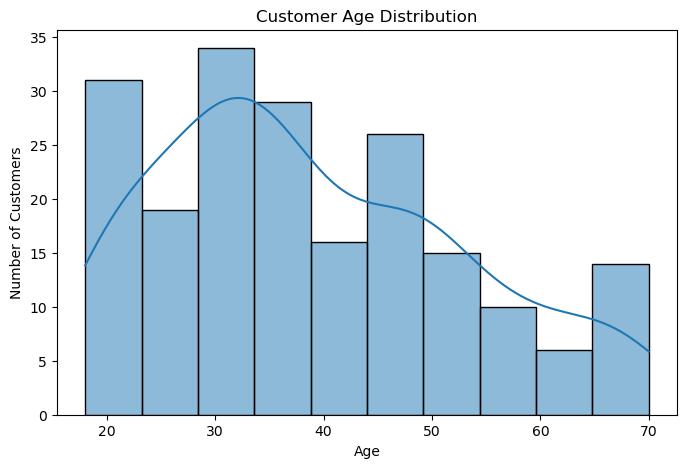

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

In [29]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status',
       'Annual Income (INR)', 'Spending Score (1-100)'],
      dtype='object')

In [30]:
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (INR),Spending Score (1-100)
0,1,M,19,High School,Married,15000,39
1,2,M,21,Graduate,Single,15000,81
2,3,F,20,Graduate,Married,16000,6
3,4,F,23,High School,Unknown,16000,77
4,5,F,31,Uneducated,Married,17000,40


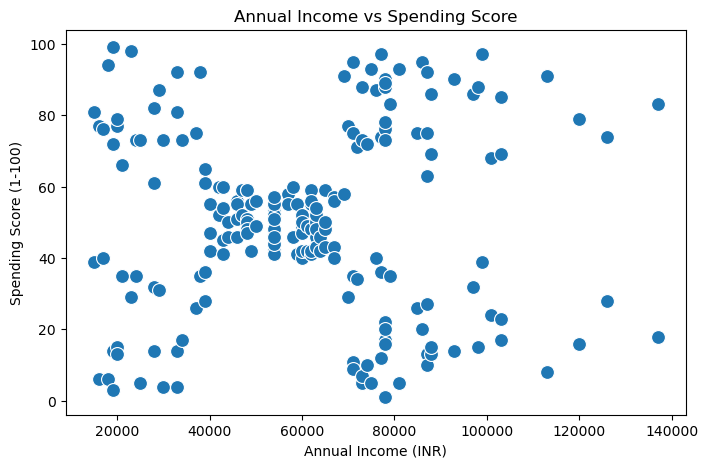

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Annual Income (INR)',
    y='Spending Score (1-100)',
    data=df,
    s=100
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (INR)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [32]:
X = df[['Annual Income (INR)', 'Spending Score (1-100)']]

X.head()

,Annual Income (INR),Spending Score (1-100)
0,15000,39
1,15000,81
2,16000,6
3,16000,77
4,17000,40


In [33]:
from sklearn.cluster import KMeans

In [37]:
X = df[['Annual Income (INR)', 'Spending Score (1-100)']]

In [38]:
X.head()

,Annual Income (INR),Spending Score (1-100)
0,15000,39
1,15000,81
2,16000,6
3,16000,77
4,17000,40


In [39]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

wcss

[137277412703.99998,
 49761869691.557625,
 25640590466.013702,
 13556961884.55869,
 10424772445.70263,
 5443747519.333723,
 4168329829.166751,
 2871761758.163294,
 2309822594.883929,
 1896214586.1073413]

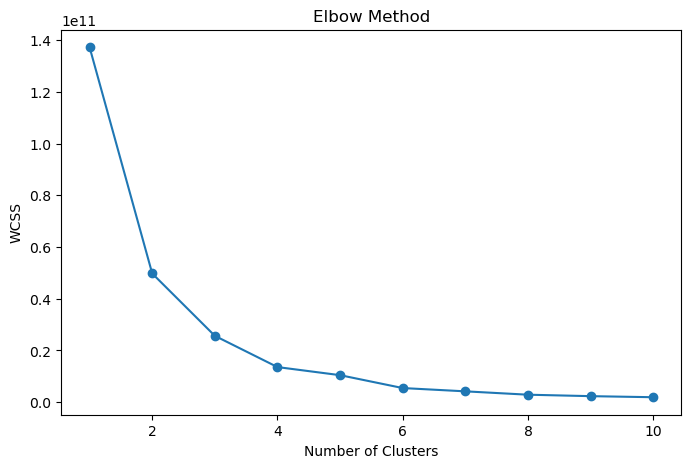

In [40]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [41]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

In [42]:
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (INR),Spending Score (1-100),Cluster
0,1,M,19,High School,Married,15000,39,2
1,2,M,21,Graduate,Single,15000,81,2
2,3,F,20,Graduate,Married,16000,6,2
3,4,F,23,High School,Unknown,16000,77,2
4,5,F,31,Uneducated,Married,17000,40,2


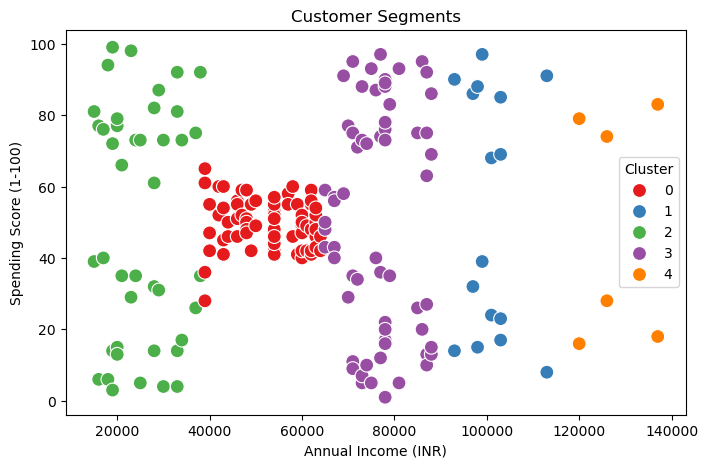

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Annual Income (INR)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (INR)")
plt.ylabel("Spending Score (1-100)")

plt.show()

In [46]:
cluster_analysis = df.groupby('Cluster')[['Age', 'Annual Income (INR)', 'Spending Score (1-100)']].mean()

cluster_analysis

,Age,Annual Income (INR),Spending Score (1-100)
Cluster,,,
0,43.472222,52500.000000,49.680556
1,37.812500,100875.000000,52.875000
2,35.119048,25095.238095,49.952381
3,36.546875,76531.250000,50.328125
4,36.833333,127666.666667,49.666667


In [47]:
df['Cluster'].value_counts()

Cluster
0    72
3    64
2    42
1    16
4     6
Name: count, dtype: int64

In [48]:
cluster_analysis = df.groupby('Cluster')[['Age', 'Annual Income (INR)', 'Spending Score (1-100)']].mean()

cluster_analysis

,Age,Annual Income (INR),Spending Score (1-100)
Cluster,,,
0,43.472222,52500.000000,49.680556
1,37.812500,100875.000000,52.875000
2,35.119048,25095.238095,49.952381
3,36.546875,76531.250000,50.328125
4,36.833333,127666.666667,49.666667


In [49]:
cluster_names = {
    0: 'Middle Income Customers',
    1: 'High Value Customers',
    2: 'Budget Customers',
    3: 'Regular Customers',
    4: 'Premium Customers'
}

df['Customer Segment'] = df['Cluster'].map(cluster_names)

df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (INR),Spending Score (1-100),Cluster,Customer Segment
0,1,M,19,High School,Married,15000,39,2,Budget Customers
1,2,M,21,Graduate,Single,15000,81,2,Budget Customers
2,3,F,20,Graduate,Married,16000,6,2,Budget Customers
3,4,F,23,High School,Unknown,16000,77,2,Budget Customers
4,5,F,31,Uneducated,Married,17000,40,2,Budget Customers


In [50]:
df['Customer Segment'].value_counts()

Customer Segment
Middle Income Customers    72
Regular Customers          64
Budget Customers           42
High Value Customers       16
Premium Customers           6
Name: count, dtype: int64

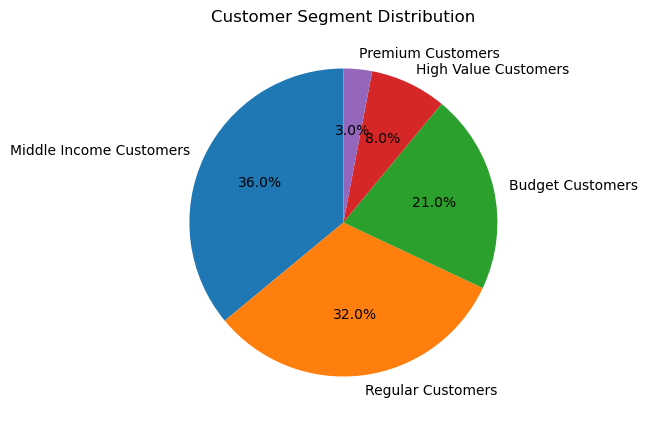

In [51]:
plt.figure(figsize=(8,5))

df['Customer Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Customer Segment Distribution")
plt.ylabel("")

plt.show()

In [52]:
segment_summary = df.groupby('Customer Segment')[['Annual Income (INR)', 'Spending Score (1-100)']].mean()

segment_summary

,Annual Income (INR),Spending Score (1-100)
Customer Segment,,
Budget Customers,25095.238095,49.952381
High Value Customers,100875.000000,52.875000
Middle Income Customers,52500.000000,49.680556
Premium Customers,127666.666667,49.666667
Regular Customers,76531.250000,50.328125


In [53]:
segment_summary = segment_summary.round(2)

segment_summary

,Annual Income (INR),Spending Score (1-100)
Customer Segment,,
Budget Customers,25095.24,49.95
High Value Customers,100875.00,52.88
Middle Income Customers,52500.00,49.68
Premium Customers,127666.67,49.67
Regular Customers,76531.25,50.33


In [54]:
customer_count = df['Customer Segment'].value_counts()

customer_count

Customer Segment
Middle Income Customers    72
Regular Customers          64
Budget Customers           42
High Value Customers       16
Premium Customers           6
Name: count, dtype: int64

In [55]:
final_summary = segment_summary.copy()

final_summary['Customer Count'] = customer_count

final_summary

,Annual Income (INR),Spending Score (1-100),Customer Count
Customer Segment,,,
Budget Customers,25095.24,49.95,42
High Value Customers,100875.00,52.88,16
Middle Income Customers,52500.00,49.68,72
Premium Customers,127666.67,49.67,6
Regular Customers,76531.25,50.33,64


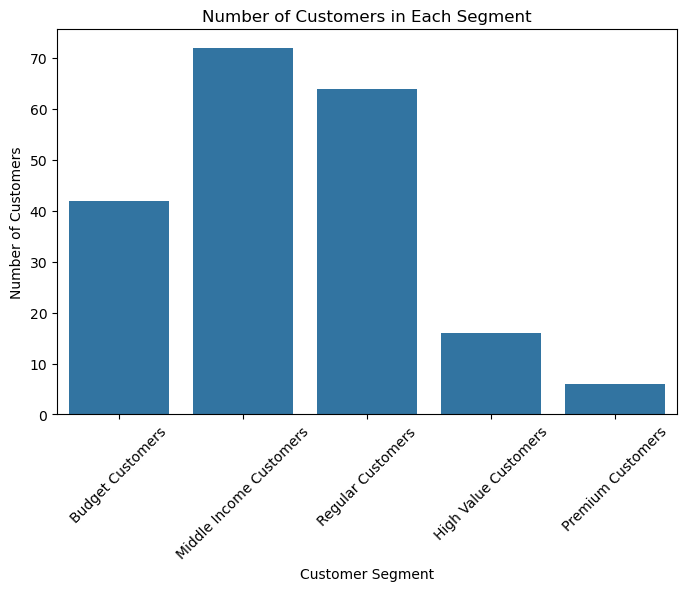

In [56]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Customer Segment',
    data=df
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()

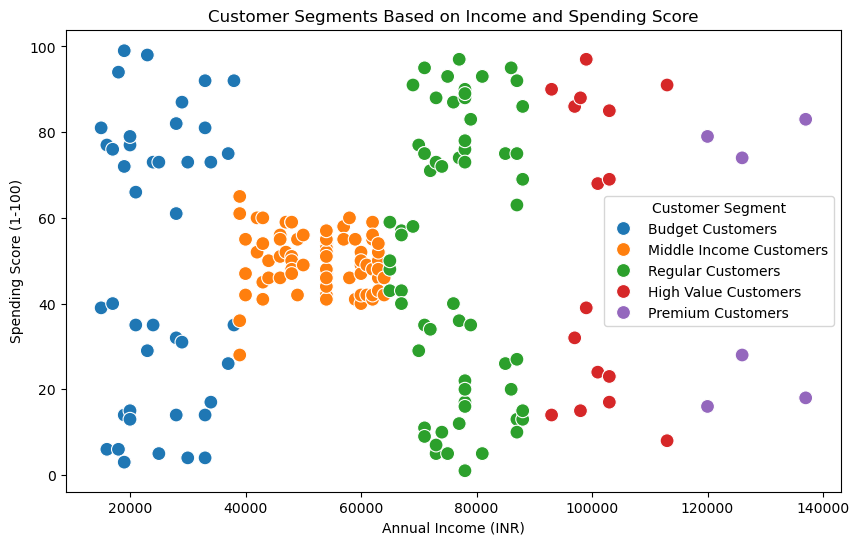

In [57]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (INR)',
    y='Spending Score (1-100)',
    hue='Customer Segment',
    data=df,
    s=100
)

plt.title("Customer Segments Based on Income and Spending Score")
plt.xlabel("Annual Income (INR)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Customer Segment")

plt.show()

<Figure size 1000x500 with 0 Axes>

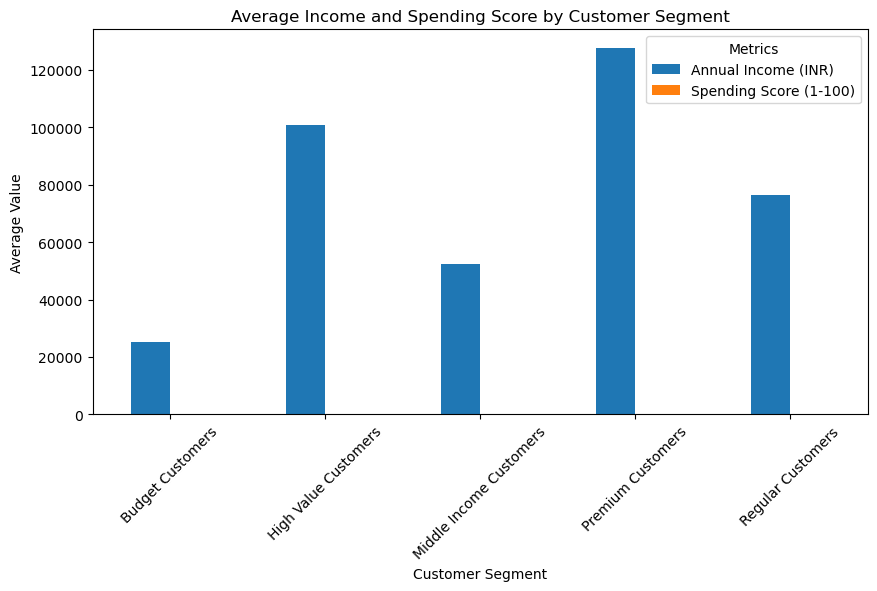

In [58]:
plt.figure(figsize=(10,5))

segment_summary[['Annual Income (INR)', 'Spending Score (1-100)']].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Income and Spending Score by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=45)

plt.legend(title="Metrics")

plt.show()

In [59]:
final_summary

,Annual Income (INR),Spending Score (1-100),Customer Count
Customer Segment,,,
Budget Customers,25095.24,49.95,42
High Value Customers,100875.00,52.88,16
Middle Income Customers,52500.00,49.68,72
Premium Customers,127666.67,49.67,6
Regular Customers,76531.25,50.33,64


In [60]:
df.to_excel("../data/customer_segmentation_final.xlsx", index=False)

In [18]:
import os
os.makedirs("images", exist_ok=True)

def save_plot(filename):
    plt.savefig(f"images/{filename}", dpi=300, bbox_inches="tight")
